In [1]:
from utils.config import RAW_CONFIG, RELEVANT_CONFIG, PROJECT_ROOT
from netCDF4 import Dataset as NETCDF4Dataset
from utils.datasettemporal import TemporalDataset
import os
from pathlib import Path

In [2]:
root = Path(PROJECT_ROOT)
filepath = root / "data/daily_small/small_daily_sample_1993-1993.nc"
dataset = TemporalDataset(filepath = filepath, normalize = True)

In [3]:
feature_map = dataset.feature_map
annotation_map = dataset.annotations_map
feature_map.shape, annotation_map.shape

((30, 6, 145, 157), (30, 1, 145, 157))

In [4]:
from sklearn.preprocessing import StandardScaler
import numpy as np

combined_map = np.concatenate((feature_map, annotation_map), axis=1)
combined_map.shape


(30, 7, 145, 157)

In [ ]:
dataset.all_variables.keys()



dict_keys(['bottomT', 'so', 'thetao', 'uo', 'vo', 'zos', 'mlotst'])

In [ ]:
import xarray as xr
ds = xr.open_dataset(filepath)
ds

<xarray.Dataset> Size: 38MB
Dimensions:    (depth: 1, latitude: 145, longitude: 157, time: 30)
Coordinates:
  * depth      (depth) float32 4B 0.494
  * latitude   (latitude) float32 580B 49.0 49.08 49.17 ... 60.83 60.92 61.0
  * longitude  (longitude) float32 628B -143.0 -142.9 -142.8 ... -130.1 -130.0
  * time       (time) datetime64[ns] 240B 1993-01-01 1993-01-02 ... 1993-01-30
Data variables:
    bottomT    (time, latitude, longitude) float64 5MB ...
    so         (time, depth, latitude, longitude) float64 5MB ...
    thetao     (time, depth, latitude, longitude) float64 5MB ...
    uo         (time, depth, latitude, longitude) float64 5MB ...
    vo         (time, depth, latitude, longitude) float64 5MB ...
    zos        (time, latitude, longitude) float64 5MB ...
    mlotst     (time, latitude, longitude) float64 5MB ...
Attributes:
    comment:                   CMEMS product
    title:                     daily mean fields from Global Ocean Physics An...
    source:                    MERCATOR GLORYS12V1
    history:                   2023/06/01 16:20:05 MERCATOR OCEAN Netcdf crea...
    institution:               MERCATOR OCEAN
    references:                http://www.mercator-ocean.fr
    Conventions:               CF-1.4
    copernicusmarine_version:  2.1.0

In [16]:
type(ds.data_vars)

xarray.core.dataset_variables.DataVariables

/mnt/c/Users/samue/.cache/pypoetry/virtualenvs/oceanpropinfsatimg-hx3efDLg-py3.12/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/mnt/c/Users/samue/.cache/pypoetry/virtualenvs/oceanpropinfsatimg-hx3efDLg-py3.12/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


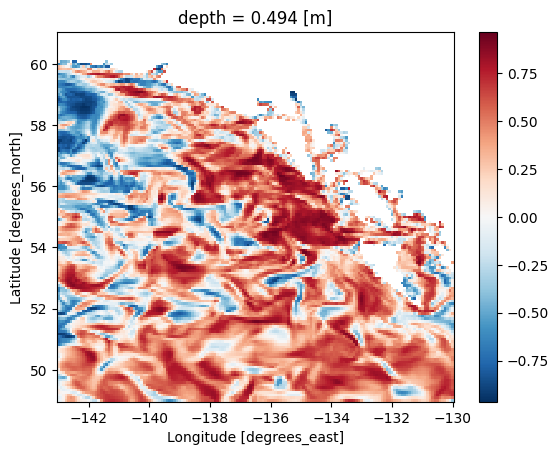

In [18]:
cors = xr.corr(ds.mlotst, ds.thetao, dim='time')
cors.plot()

/mnt/c/Users/samue/.cache/pypoetry/virtualenvs/oceanpropinfsatimg-hx3efDLg-py3.12/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/mnt/c/Users/samue/.cache/pypoetry/virtualenvs/oceanpropinfsatimg-hx3efDLg-py3.12/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/mnt/c/Users/samue/.cache/pypoetry/virtualenvs/oceanpropinfsatimg-hx3efDLg-py3.12/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/mnt/c/Users/samue/.cache/pypoetry/virtualenvs/oceanpropinfsatimg-hx3efDLg-py3.12/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar

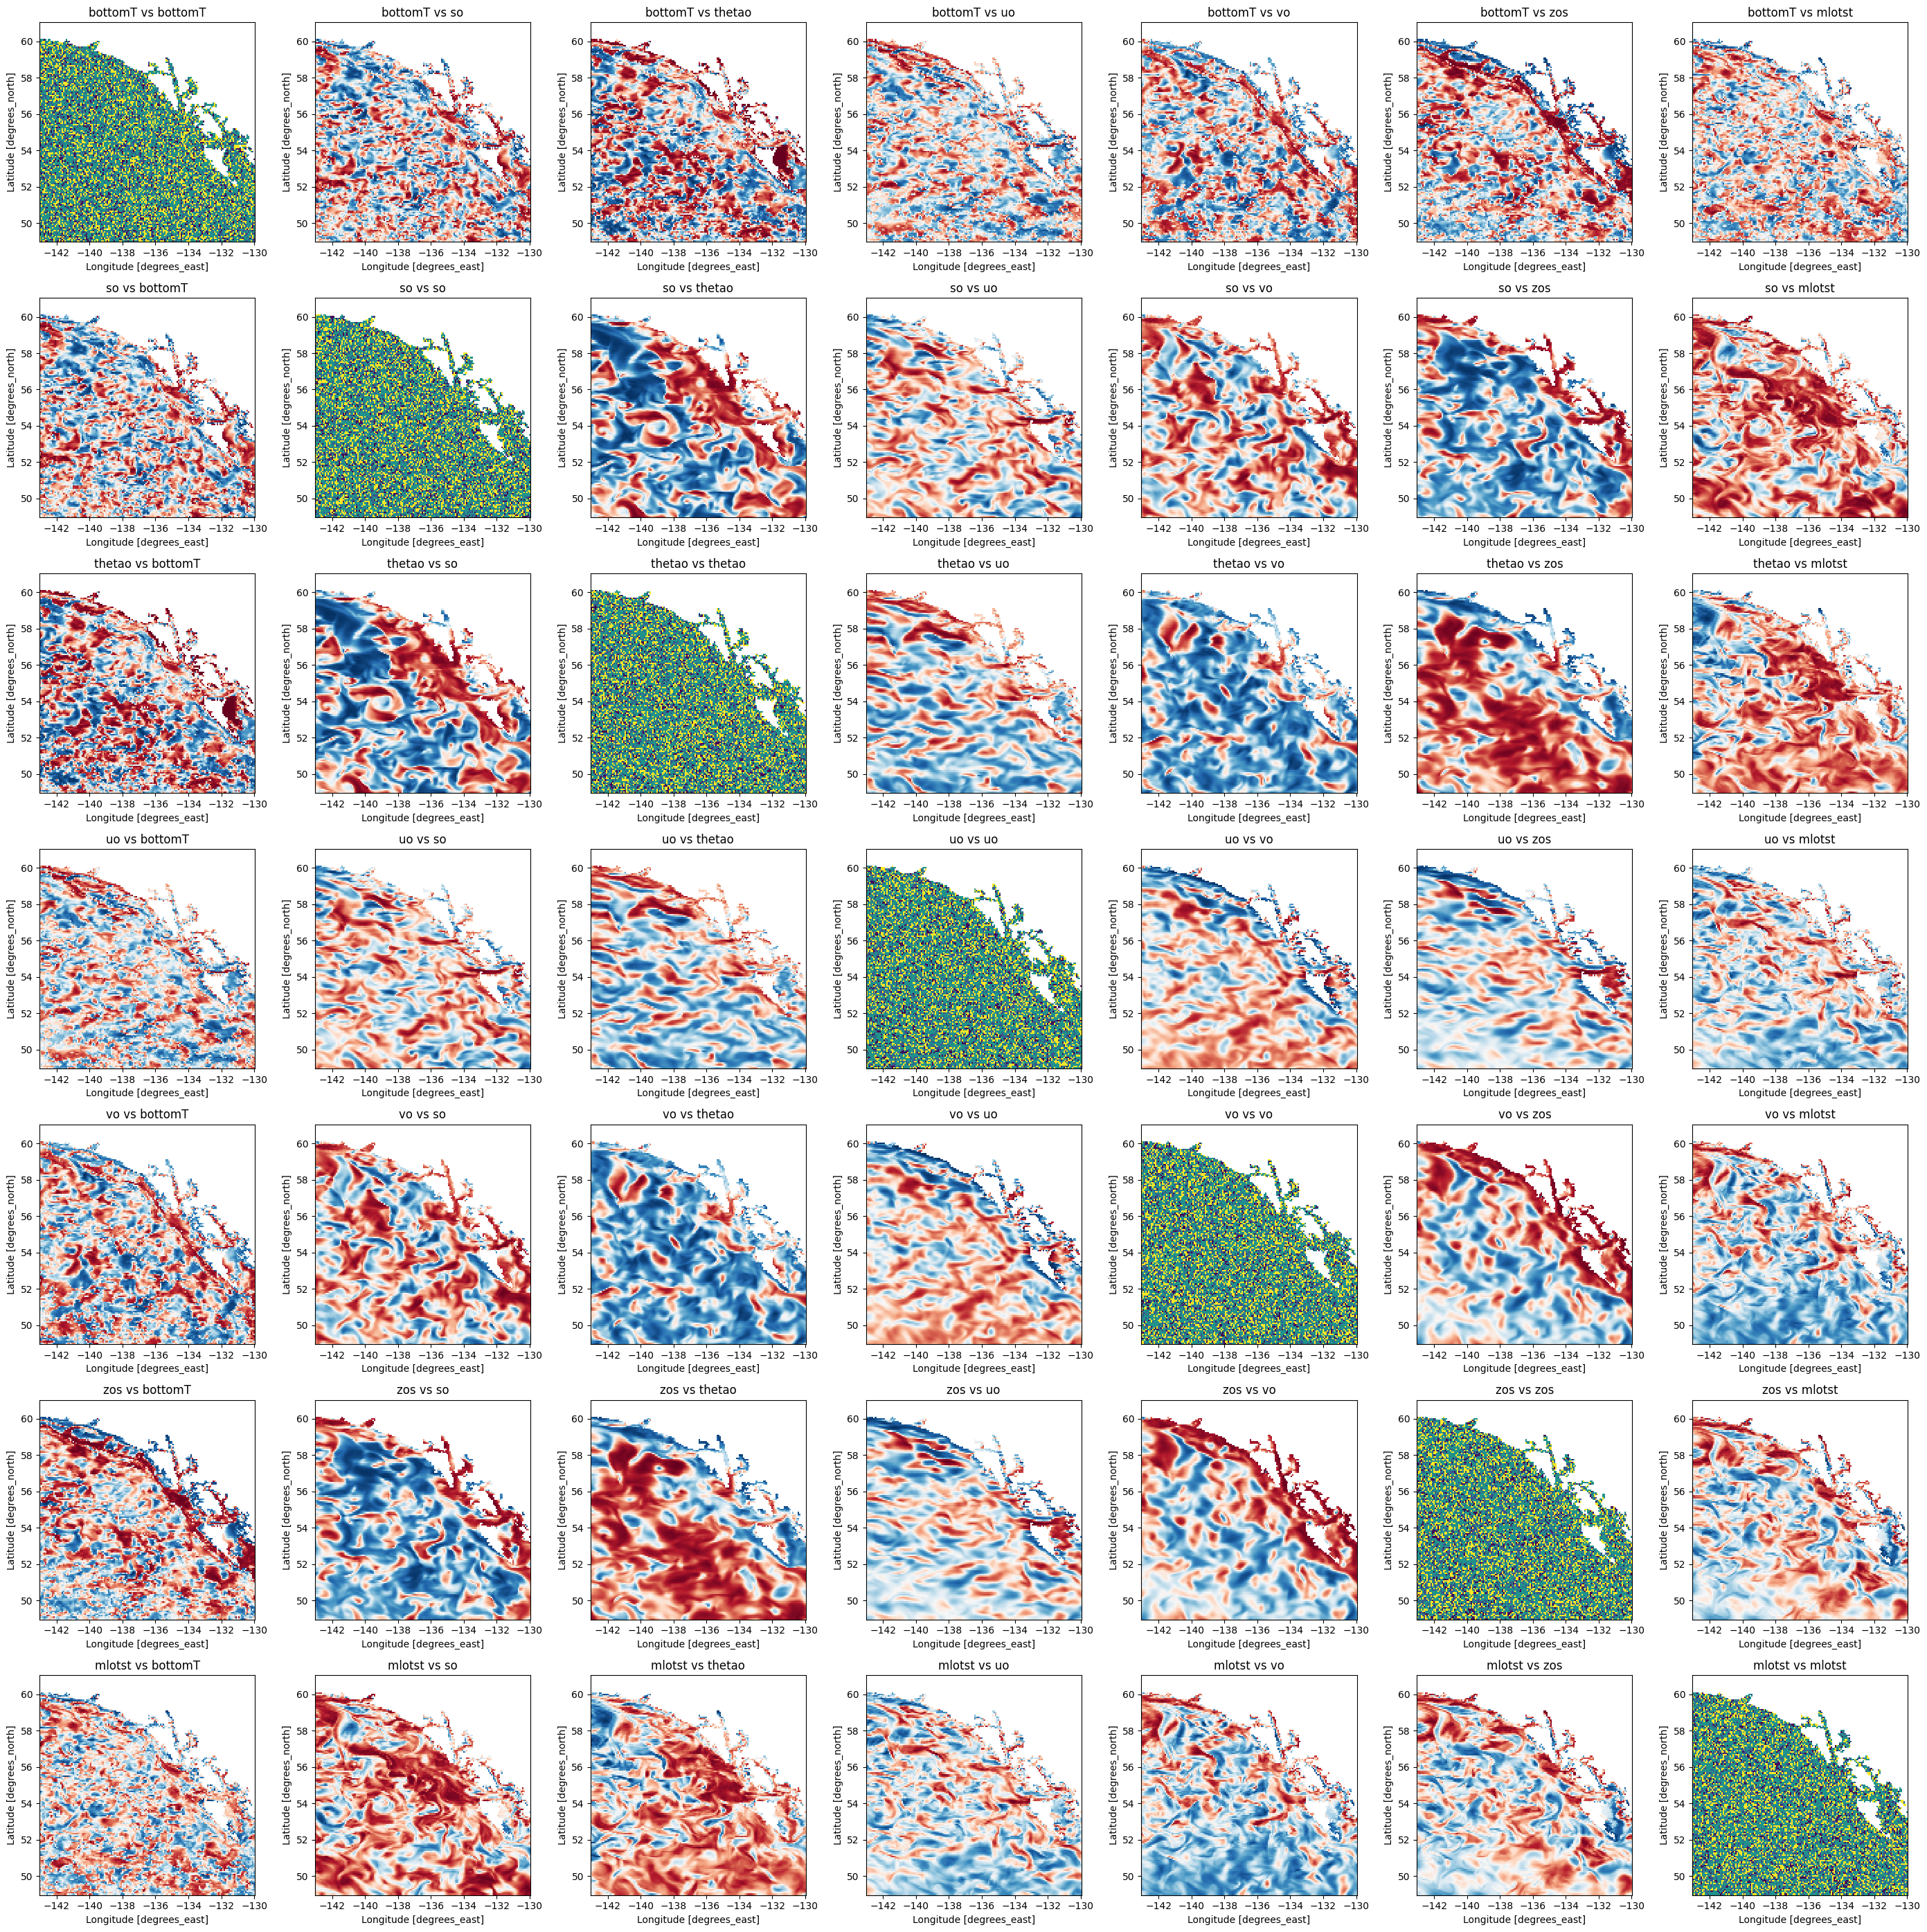

In [23]:
import matplotlib.pyplot as plt

variables = list(ds.data_vars)
n = len(variables)

fig, axes = plt.subplots(n, n, figsize=(4*n, 4*n))

for i, var1 in enumerate(variables):
    for j, var2 in enumerate(variables):
        # Only compute correlation if dimensions overlap
        try:
            cors = xr.corr(ds[var1], ds[var2], dim='time')
            # If depth exists, select the first depth for plotting
            if 'depth' in cors.dims:
                cors = cors.isel(depth=0)
            ax = axes[i, j]
            cors.plot(ax=ax, add_colorbar=False)
            ax.set_title(f"{var1} vs {var2}")
        except Exception as e:
            axes[i, j].set_visible(False)
plt.tight_layout()
plt.show()


In [24]:
ds['mlotst']

<xarray.DataArray 'mlotst' (time: 30, latitude: 145, longitude: 157)> Size: 5MB
[682950 values with dtype=float64]
Coordinates:
  * latitude   (latitude) float32 580B 49.0 49.08 49.17 ... 60.83 60.92 61.0
  * longitude  (longitude) float32 628B -143.0 -142.9 -142.8 ... -130.1 -130.0
  * time       (time) datetime64[ns] 240B 1993-01-01 1993-01-02 ... 1993-01-30
Attributes:
    standard_name:  ocean_mixed_layer_thickness_defined_by_sigma_theta
    units:          m
    valid_max:      4525
    valid_min:      1
    unit_long:      Meters
    long_name:      Density ocean mixed layer thickness

In [29]:
from eofs.xarray import Eof
solver = Eof(ds[['time','thetao', 'mlotst']].to_array('feature'))
eofs = solver.eofs(neofs=3)
pcs = solver.pcs(npcs=3, pcscaling=1)
eofs.plot

ValueError: time must be the first dimension, consider using the transpose() method

In [26]:
coarse_ds = ds.coarsen(latitude=3, longitude=3, boundary='trim').mean()


/mnt/c/Users/samue/.cache/pypoetry/virtualenvs/oceanpropinfsatimg-hx3efDLg-py3.12/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/mnt/c/Users/samue/.cache/pypoetry/virtualenvs/oceanpropinfsatimg-hx3efDLg-py3.12/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/mnt/c/Users/samue/.cache/pypoetry/virtualenvs/oceanpropinfsatimg-hx3efDLg-py3.12/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/mnt/c/Users/samue/.cache/pypoetry/virtualenvs/oceanpropinfsatimg-hx3efDLg-py3.12/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar

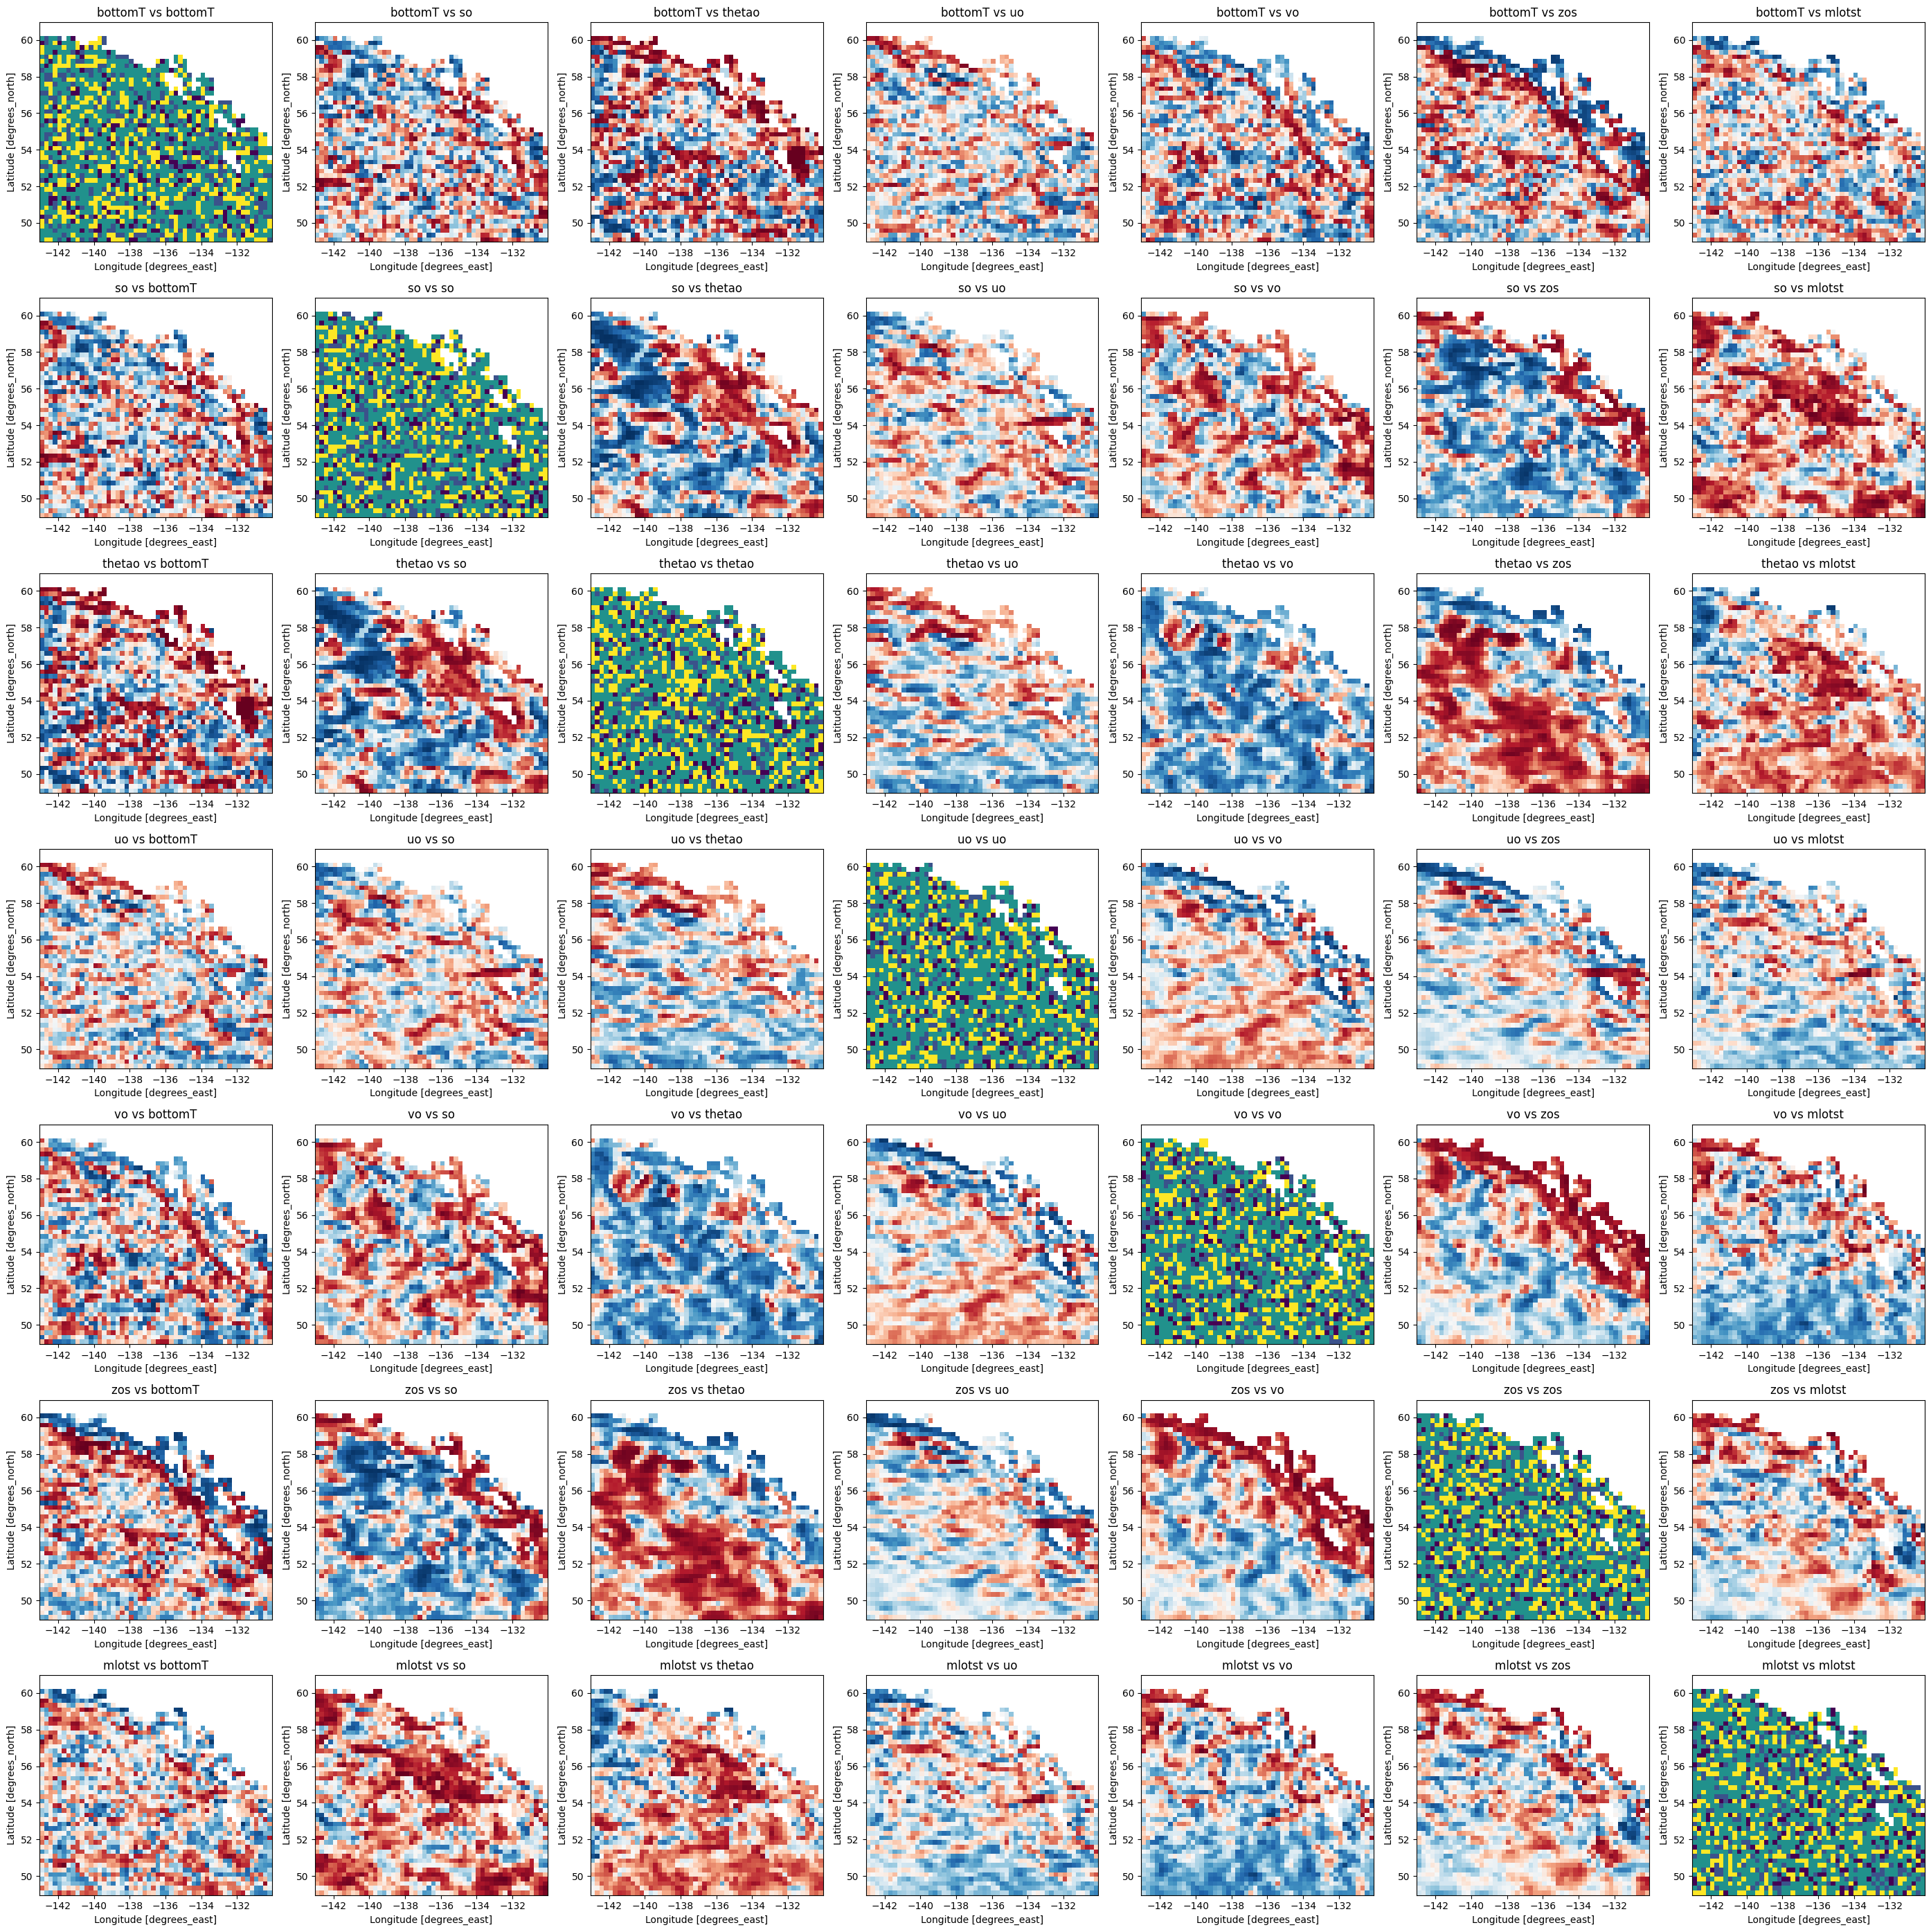

In [27]:
import matplotlib.pyplot as plt



variables = list(coarse_ds.data_vars)
n = len(variables)

fig, axes = plt.subplots(n, n, figsize=(4*n, 4*n))

for i, var1 in enumerate(variables):
    for j, var2 in enumerate(variables):
        # Only compute correlation if dimensions overlap
        try:
            cors = xr.corr(coarse_ds[var1], coarse_ds[var2], dim='time')
            # If depth exists, select the first depth for plotting
            if 'depth' in cors.dims:
                cors = cors.isel(depth=0)
            ax = axes[i, j]
            cors.plot(ax=ax, add_colorbar=False)
            ax.set_title(f"{var1} vs {var2}")
        except Exception as e:
            axes[i, j].set_visible(False)
plt.tight_layout()
plt.show()
